In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.path import Path
from matplotlib.patches import PathPatch
import matplotlib
import colormaps as cmaps
from matplotlib.colors import ListedColormap
import pandas as pd

GPP_baseline = xr.open_dataset("/projects/prjs2023/chapter3/lpjml_output/2026_01_29_baseline_run/baseline_withfire/output/mgpp.nc").GPP.sel(time = slice('2000-03','2019'))
# Convert CFTimeIndex to pandas datetime
time_as_timestamp = pd.to_datetime(GPP_baseline["time"].values.astype(str))

# Convert to period
time_as_period = time_as_timestamp.to_period("M")
time_as_timestamp = time_as_period.to_timestamp(how="start")

# Update the time coordinate in the DataArray
GPP_baseline = GPP_baseline.assign_coords(time=time_as_timestamp)
GPP_baseline

<xarray.DataArray 'GPP' (time: 238, lat: 1397, lon: 3600)> Size: 5GB
[1196949600 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[us] 2kB 2000-03-01 2000-04-01 ... 2019-12-01
  * lat      (lat) float64 11kB -55.95 -55.85 -55.75 ... 83.45 83.55 83.65
  * lon      (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.8 179.9 180.0
Attributes:
    units:          gC/m2/month
    standard_name:  GPP
    long_name:      GPP

In [2]:
GPP_monthlymort = xr.open_dataset("/projects/prjs2023/chapter3/lpjml_output/2026_01_29_baseline_run/monthlybackground_withfire/output/mgpp.nc").GPP.sel(time = slice('2000-03','2019'))
# Convert CFTimeIndex to pandas datetime
time_as_timestamp = pd.to_datetime(GPP_monthlymort["time"].values.astype(str))

# Convert to period
time_as_period = time_as_timestamp.to_period("M")
time_as_timestamp = time_as_period.to_timestamp(how="start")

# Update the time coordinate in the DataArray
GPP_monthlymort = GPP_monthlymort.assign_coords(time=time_as_timestamp)
GPP_monthlymort

<xarray.DataArray 'GPP' (time: 238, lat: 1397, lon: 3600)> Size: 5GB
[1196949600 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[us] 2kB 2000-03-01 2000-04-01 ... 2019-12-01
  * lat      (lat) float64 11kB -55.95 -55.85 -55.75 ... 83.45 83.55 83.65
  * lon      (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.8 179.9 180.0
Attributes:
    units:          gC/m2/month
    standard_name:  GPP
    long_name:      GPP

In [3]:
GPP_droughtmort = xr.open_dataset("/projects/prjs2023/chapter3/lpjml_output/2026_04_23_global_droughtmort_new/withfire/output/mgpp.nc").GPP.sel(time = slice('2000-03','2019'))
# Convert CFTimeIndex to pandas datetime
time_as_timestamp = pd.to_datetime(GPP_droughtmort["time"].values.astype(str))

# Convert to period
time_as_period = time_as_timestamp.to_period("M")
time_as_timestamp = time_as_period.to_timestamp(how="start")

# Update the time coordinate in the DataArray
GPP_droughtmort = GPP_droughtmort.assign_coords(time=time_as_timestamp)
GPP_droughtmort

<xarray.DataArray 'GPP' (time: 238, lat: 1397, lon: 3600)> Size: 5GB
[1196949600 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[us] 2kB 2000-03-01 2000-04-01 ... 2019-12-01
  * lat      (lat) float64 11kB -55.95 -55.85 -55.75 ... 83.45 83.55 83.65
  * lon      (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.8 179.9 180.0
Attributes:
    units:          gC/m2/month
    standard_name:  GPP
    long_name:      GPP

In [4]:
GPP_MODIS = xr.open_dataset("/projects/prjs2023/chapter3/MODIS/GPP_MODIS_landseamask_01deg.nc").Gpp.sel(time = slice('2000-03','2019'))
# Convert CFTimeIndex to pandas datetime
time_as_timestamp = pd.to_datetime(GPP_MODIS["time"].values.astype(str))

# Convert to period
time_as_period = time_as_timestamp.to_period("M")
time_as_timestamp = time_as_period.to_timestamp(how="start")

# Update the time coordinate in the DataArray
GPP_MODIS = GPP_MODIS.assign_coords(time=time_as_timestamp)
GPP_MODIS

<xarray.DataArray 'Gpp' (time: 238, lat: 1397, lon: 3600)> Size: 10GB
[1196949600 values with dtype=float64]
Coordinates:
  * time     (time) datetime64[us] 2kB 2000-03-01 2000-04-01 ... 2019-12-01
  * lat      (lat) float64 11kB -55.95 -55.85 -55.75 ... 83.45 83.55 83.65
  * lon      (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.8 179.9 180.0

In [5]:
GPP_baseline['lon'] = GPP_monthlymort.lon
GPP_baseline['lat'] = GPP_monthlymort.lat
GPP_MODIS['lon'] = GPP_monthlymort.lon
GPP_MODIS['lat'] = GPP_monthlymort.lat
GPP_droughtmort['lon'] = GPP_monthlymort.lon
GPP_droughtmort['lat'] = GPP_monthlymort.lat

In [6]:
lc = xr.open_dataset("/projects/prjs2023/chapter3/landcover/C3S-LC-L4-LCCS-Map-01deg_remapnn-P1Y-2022-v2.1.1.nc").lccs_class[0].sel(lat = slice(-56.0,83.7))
lc['lat'] = GPP_monthlymort.lat
lc['lon'] = GPP_monthlymort.lon
valid_mask = (lc != 220) & (lc != 210) & (lc != 200) & (lc != 150)

In [7]:
# Step 1: Rename variables before merging
GPP_MODIS = GPP_MODIS.rename("GPP_MODIS").where(valid_mask)
LPJML_monthlymort = GPP_monthlymort.rename("GPP_LPJML_monthlymort").where(valid_mask)
LPJML_baseline = GPP_baseline.rename("GPP_LPJML_baseline").where(valid_mask)
LPJML_droughtmort = GPP_droughtmort.rename("GPP_LPJML_droughtmort").where(valid_mask)

# Step 2: Merge datasets
ds = xr.merge([GPP_MODIS, LPJML_monthlymort, LPJML_baseline, LPJML_droughtmort])
# ds = ds.reset_coords("time", drop=True)
ds

<xarray.Dataset> Size: 24GB
Dimensions:                (time: 238, lon: 3600, lat: 1397)
Coordinates:
  * time                   (time) datetime64[us] 2kB 2000-03-01 ... 2019-12-01
  * lon                    (lon) float64 29kB -179.9 -179.8 ... 179.9 180.0
  * lat                    (lat) float64 11kB -55.95 -55.85 ... 83.55 83.65
Data variables:
    GPP_MODIS              (time, lat, lon) float64 10GB nan nan nan ... nan nan
    GPP_LPJML_monthlymort  (time, lat, lon) float32 5GB nan nan nan ... nan nan
    GPP_LPJML_baseline     (time, lat, lon) float32 5GB nan nan nan ... nan nan
    GPP_LPJML_droughtmort  (time, lat, lon) float32 5GB nan nan nan ... nan nan

In [8]:
import pandas as pd

def find_droughts(spei, region_name):
    """
    Identifies multi-year (>=12 months) and normal (<12 months) droughts.

    Parameters:
    - spei: xarray DataArray with 'time' dimension
    - region_name: str

    Returns:
    - my_start, my_end, my_length: lists for multi-year droughts
    - nd_start, nd_end, nd_length: lists for normal droughts
    """
    print(f"Analyzing droughts for region: {region_name}")
    
    i = 0
    start = None
    start_drought = None

    my_start, my_end, my_length = [], [], []
    nd_start, nd_end, nd_length = [], [], []

    for t in spei.time:
        if spei.sel(time=t).mean() <= -1:
            i += 1
            if i == 1:
                start = t
                start_drought = t.values
            # Handle edge case at end
            if t == spei.time[-1] and i > 0:
                end = t
                if i >= 12:
                    my_start.append(start)
                    my_end.append(end)
                    my_length.append(i)
                    print(f"Multi-year drought: {start_drought} to {end.values} ({i} months)")
                else:
                    nd_start.append(start)
                    nd_end.append(end)
                    nd_length.append(i)
                    print(f"Normal drought: {start_drought} to {end.values} ({i} months)")
        else:
            if i > 0:
                end = spei.time.sel(time=t.values - pd.DateOffset(months=1))
                if i >= 12:
                    my_start.append(start)
                    my_end.append(end)
                    my_length.append(i)
                    print(f"Multi-year drought: {start_drought} to {end.values} ({i} months)")
                else:
                    nd_start.append(start)
                    nd_end.append(end)
                    nd_length.append(i)
                    print(f"Normal drought: {start_drought} to {end.values} ({i} months)")
            i = 0
            start = None
            start_drought = None

    return my_start, my_end, my_length, nd_start, nd_end, nd_length


In [9]:
def standardized_anomalies(data, start_year=2000, end_year=2019):
    # Select the reference period for standardization
    data_ref = data.sel(time=slice(f"{start_year}-01-01", f"{end_year}-12-31"))
    
    # Compute climatology and standard deviation over the reference period
    climatology_mean = data_ref.groupby('time.month').mean('time')
    climatology_std = data_ref.groupby('time.month').std('time')
    
    # Check if climatology_std is not zero
    climatology_std_nonzero = climatology_std.where(climatology_std != 0)
    
    # Calculate standardized anomalies only where climatology_std is not zero
    stand_anomalies = xr.apply_ufunc(lambda x, m, s: (x - m) / s if s != 0 else np.nan, 
                                      data.groupby('time.month'), climatology_mean, climatology_std_nonzero,
                                      dask='allowed', vectorize=True)
    print('anomalies done')
    return stand_anomalies

In [10]:
def precompute_all_regions(
    gpp_datasets,           # dict: {"name": xarray DataArray}
    region_settings,
    base_spei_path,
    base_mask_path,
    zoom_start,
    zoom_end
):

    precomputed_results = {}

    for region_name, spei_file, mask_file, lat, lon in region_settings:

        # === Load SPEI and mask ===
        SPEI = xr.open_dataset(base_spei_path + spei_file).__xarray_dataarray_variable__
        mask = xr.open_dataarray(base_mask_path + mask_file).sel(lat=lat, lon=lon)

        # === Drought detection ===
        droughts = find_droughts(SPEI, region_name)
        start_dates_MYD, end_dates_MYD = droughts[0], droughts[1]
        start_dates_ND, end_dates_ND = droughts[3], droughts[4]

        # === Process ALL datasets ===
        region_data = {}

        for name, gpp in gpp_datasets.items():

            ts = gpp.sel(lat=lat, lon=lon).where(mask == 1).mean(['lon', 'lat'])

            ts_std = standardized_anomalies(ts)

            # Align time if needed (important for MODIS)
            ts_std['time'] = ts_std.time

            ts_zoom = ts_std.sel(time=slice(zoom_start, zoom_end)).to_pandas()

            region_data[name] = ts_zoom

        # === SPEI zoom ===
        spei_zoom = SPEI.sel(time=slice(zoom_start, zoom_end))

        # === Store everything ===
        precomputed_results[region_name] = {
            'gpp': region_data,   # <-- all datasets here
            'spei_zoom': spei_zoom,
            'start_dates_MYD': start_dates_MYD,
            'end_dates_MYD': end_dates_MYD,
            'start_dates_ND': start_dates_ND,
            'end_dates_ND': end_dates_ND,
        }

    print("Precomputation done.")
    return precomputed_results

In [11]:
region_settings = [
    ("CAL", "SPEI12_monthly_1950_2019_0_5_degree_CAL.nc", "mask_CAL_0_1_degrees.nc", slice(30, 43), slice(-126, -113)),
    ("WEU", "SPEI12_monthly_1950_2019_0_5_degree_WEU.nc", "mask_WEU_0_1_degrees.nc", slice(41, 57), slice(-2, 14)),
    ("BRA", "SPEI12_monthly_1950_2019_0_5_degree_BAH.nc", "mask_Brahmaputra_0_1_degrees.nc", slice(19, 37), slice(81, 99)),
    ("ARG", "SPEI12_monthly_1950_2019_0_5_degree_ARG.nc", "mask_ARG_0_1_degrees.nc", slice(-56, -26), slice(-80, -50)),
    ("SA", "SPEI12_monthly_1950_2019_0_5_degree_SA.nc", "mask_SA_0_1_degrees.nc", slice(-37, -15), slice(13, 35)),
    ("AUS", "SPEI12_monthly_1950_2019_0_5_degree_AUS.nc", "mask_AUS_0_1_degrees.nc", slice(-39.9, -19.9), slice(135, 155)),    
]

base_spei_path = "/projects/prjs2023/chapter3/SPEI/focus_regions/"
base_mask_path = "/projects/prjs2023/chapter3/remapped_masks/"
zoom_start = "2000-01-01"
zoom_end = "2019-12-31"

# Step 1: heavy calculation done once
gpp_datasets = {
    "Baseline": ds.GPP_LPJML_baseline,
    "Monthly mort": ds.GPP_LPJML_monthlymort,
    "Drought mort": ds.GPP_LPJML_droughtmort,
    "MODIS": ds.GPP_MODIS
}

results = precompute_all_regions(
    gpp_datasets=gpp_datasets,
    region_settings=region_settings,
    base_spei_path=base_spei_path,
    base_mask_path=base_mask_path,
    zoom_start=zoom_start,
    zoom_end=zoom_end
)

Analyzing droughts for region: CAL
Normal drought: 1910-12-01T00:00:00.000000000 to 1910-12-01T00:00:00.000000000 (1 months)
Normal drought: 1912-02-01T00:00:00.000000000 to 1912-03-01T00:00:00.000000000 (2 months)
Normal drought: 1913-10-01T00:00:00.000000000 to 1913-10-01T00:00:00.000000000 (1 months)
Normal drought: 1917-12-01T00:00:00.000000000 to 1918-02-01T00:00:00.000000000 (3 months)
Normal drought: 1920-02-01T00:00:00.000000000 to 1920-02-01T00:00:00.000000000 (1 months)
Normal drought: 1923-12-01T00:00:00.000000000 to 1924-02-01T00:00:00.000000000 (3 months)
Normal drought: 1924-04-01T00:00:00.000000000 to 1925-01-01T00:00:00.000000000 (10 months)
Normal drought: 1929-03-01T00:00:00.000000000 to 1929-03-01T00:00:00.000000000 (1 months)
Normal drought: 1929-11-01T00:00:00.000000000 to 1929-12-01T00:00:00.000000000 (2 months)
Normal drought: 1931-05-01T00:00:00.000000000 to 1931-05-01T00:00:00.000000000 (1 months)
Normal drought: 1931-09-01T00:00:00.000000000 to 1931-11-01T00:0

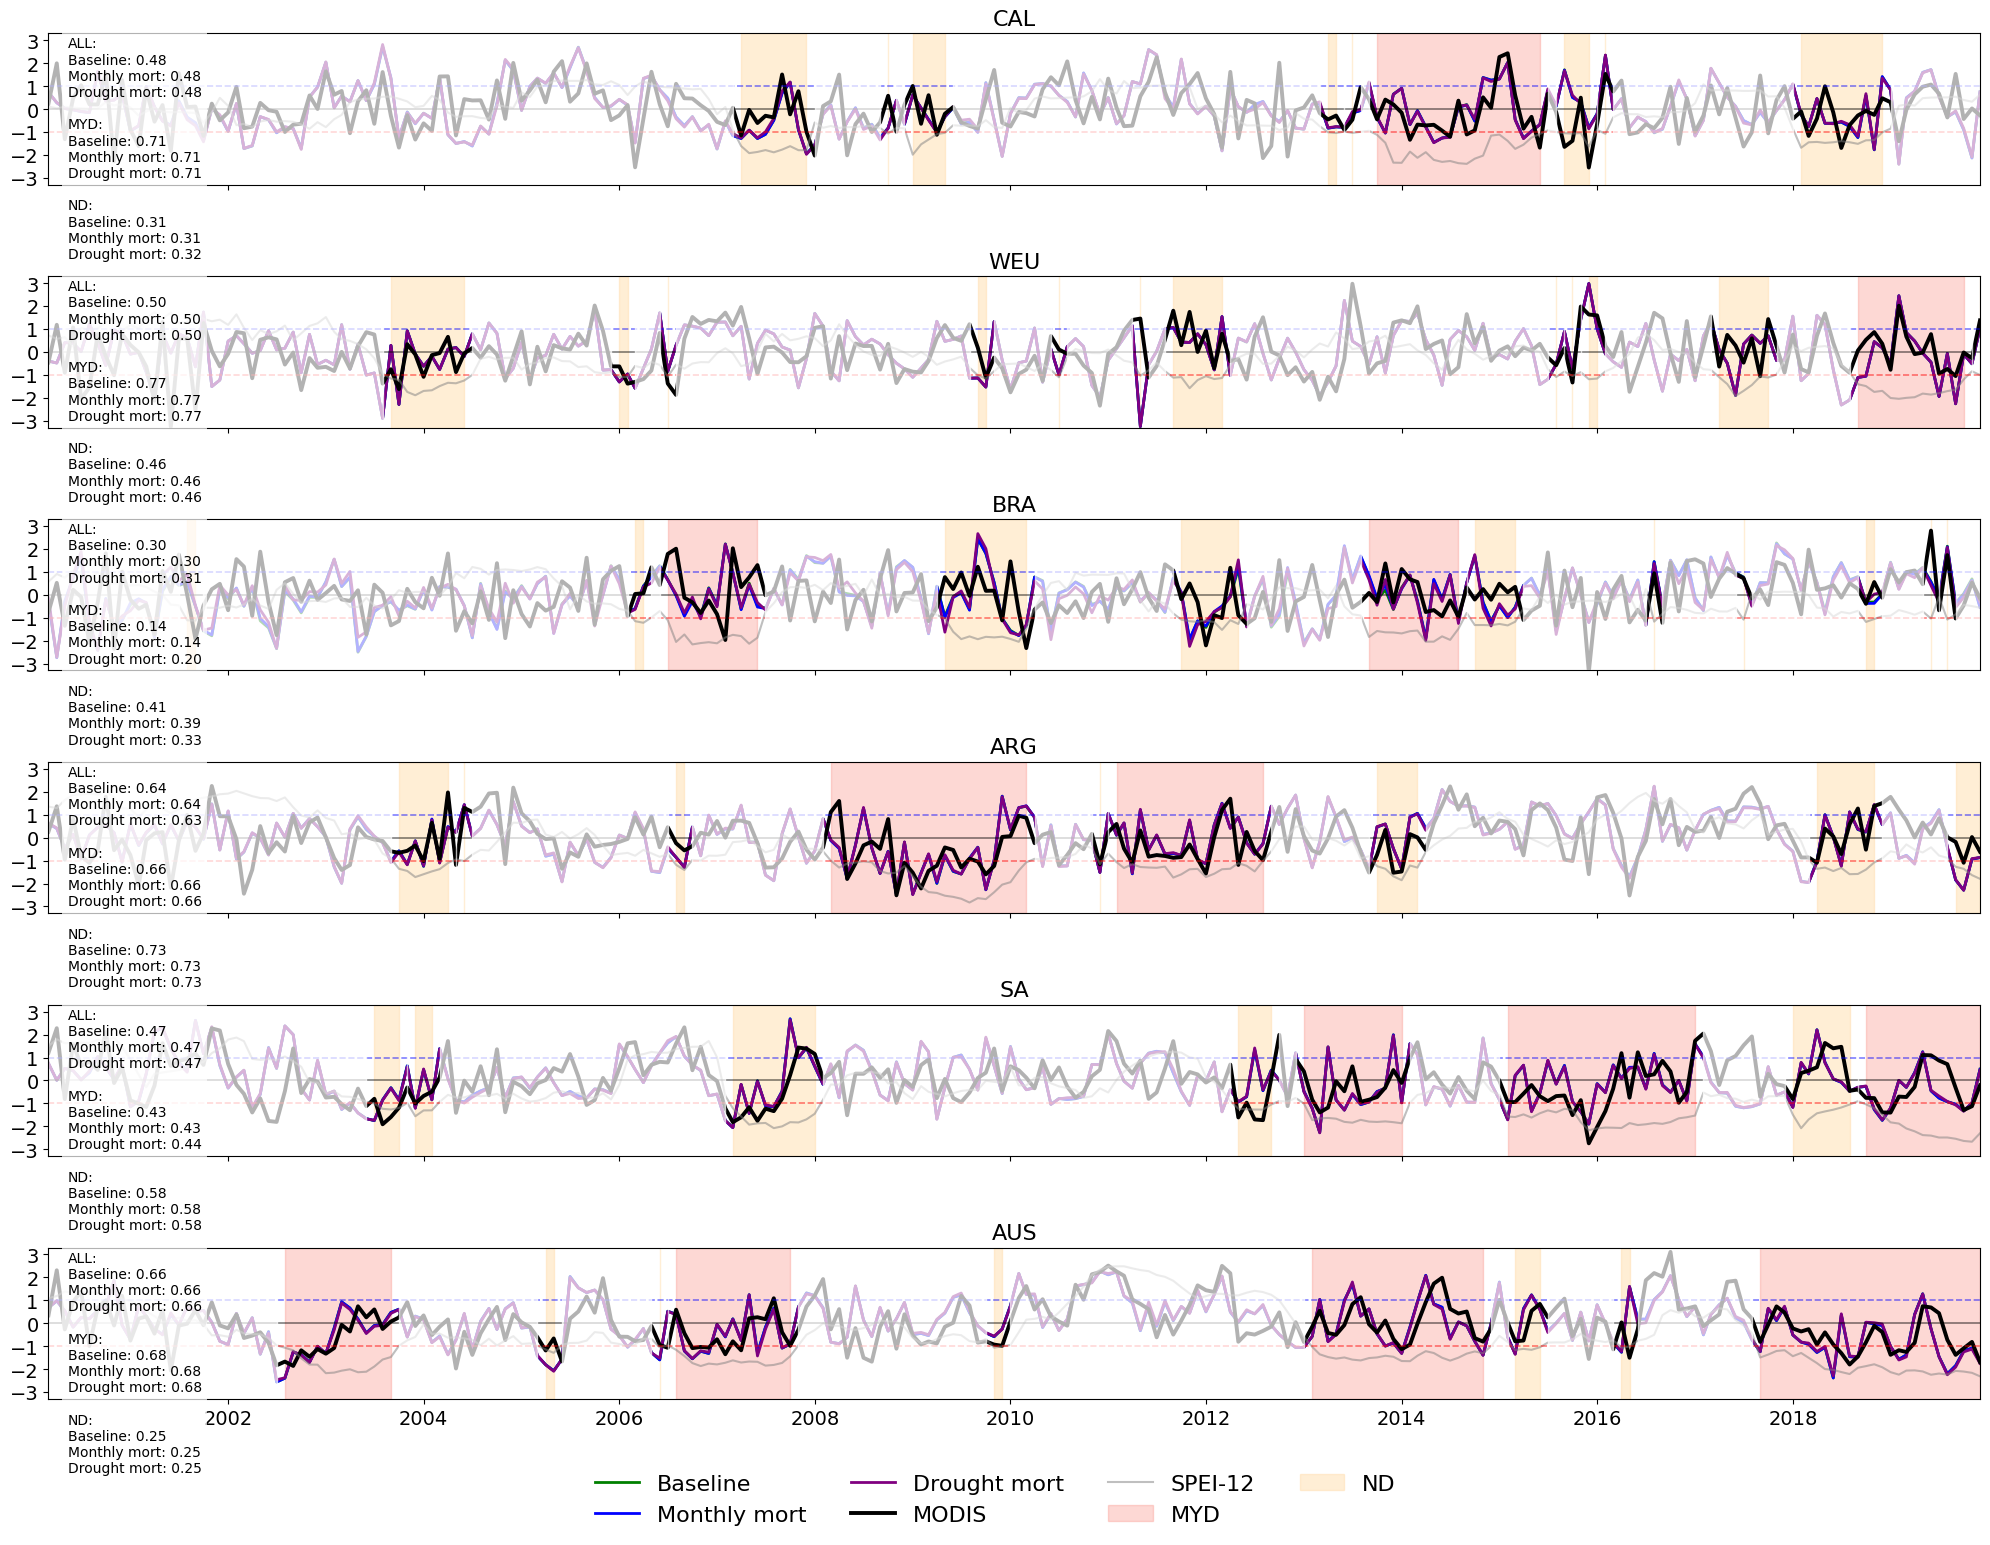

: 

In [ ]:
def plot_all_regions(precomputed_results, region_settings):

    fig, axs = plt.subplots(len(region_settings), 1, figsize=(20, 16), tight_layout=True, sharex=True)
    axs = axs.flatten()

    handles = []
    labels = []

    colors = {
        "Baseline": "green",
        "Monthly mort": "blue",
        "Drought mort": "purple",
        "MODIS": "black"
    }

    for i, (region_name, *_ ) in enumerate(region_settings):
        data = precomputed_results[region_name]
        ax = axs[i]

        gpp_data = data['gpp']
        modis = gpp_data["MODIS"]
        time_index = modis.index

        # === Plot all datasets ===
        for name, ts in gpp_data.items():
            ax.plot(
                ts.index,
                ts,
                color=colors.get(name, "gray"),
                linewidth=2.8 if name == "MODIS" else 2,
                linestyle="solid",
                label=name
            )

        # === Correlations ===
        corr_text = []
        corr_myd_text = []
        corr_nd_text = []

        for name, ts in gpp_data.items():
            if name == "MODIS":
                continue

            # --- ALL correlation ---
            corr = ts.corr(modis)
            corr_text.append(f"{name}: {corr:.2f}")

            # --- MYD mask ---
            myd_mask = np.full(len(modis), False)
            for start, end in zip(data['start_dates_MYD'], data['end_dates_MYD']):
                start_dt = pd.to_datetime(str(start.values))
                end_dt = pd.to_datetime(str(end.values))
                mask = (time_index >= start_dt) & (time_index <= end_dt)
                myd_mask |= mask

            if myd_mask.any():
                corr_myd = ts[myd_mask].corr(modis[myd_mask])
            else:
                corr_myd = np.nan

            # --- ND mask ---
            nd_mask = np.full(len(modis), False)
            for start, end in zip(data['start_dates_ND'], data['end_dates_ND']):
                start_dt = pd.to_datetime(str(start.values))
                end_dt = pd.to_datetime(str(end.values))
                mask = (time_index >= start_dt) & (time_index <= end_dt)
                nd_mask |= mask

            if nd_mask.any():
                corr_nd = ts[nd_mask].corr(modis[nd_mask])
            else:
                corr_nd = np.nan

            corr_myd_text.append(f"{name}: {corr_myd:.2f}")
            corr_nd_text.append(f"{name}: {corr_nd:.2f}")

        # === SPEI line ===
        ax.plot(data['spei_zoom'].time, data['spei_zoom'], color="gray", linewidth=1.5, alpha=0.5, label="SPEI-12")

        # === Drought shading ===
        labeled_myd = False
        for start, end in zip(data['start_dates_MYD'], data['end_dates_MYD']):
            spei_subset = data['spei_zoom'].sel(time=slice(start, end))
            if (spei_subset <= -1).any():
                ax.fill_between(
                    spei_subset.time, y1=-3.3, y2=3.3,
                    color="salmon", alpha=0.3, zorder=1,
                    label="MYD" if not labeled_myd else None
                )
                labeled_myd = True

        labeled_nd = False
        for start, end in zip(data['start_dates_ND'], data['end_dates_ND']):
            spei_subset = data['spei_zoom'].sel(time=slice(start, end))
            if (spei_subset <= -1).any():
                ax.fill_between(
                    spei_subset.time, y1=-3.3, y2=3.3,
                    color="navajowhite", alpha=0.5, zorder=1,
                    label="ND" if not labeled_nd else None
                )
                labeled_nd = True

        # === Threshold lines ===
        ax.axhline(y=-1, color="red", linestyle="dashed", linewidth=1.2, alpha=0.5)
        ax.axhline(y=1, color="blue", linestyle="dashed", linewidth=1.2, alpha=0.5)
        ax.axhline(y=0, color="black", linewidth=1.2, alpha=0.5)

        ax.set_ylim([-3.3, 3.3])
        ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=7))
        ax.set_xlim([time_index[0], time_index[-1]])

        # === Title ===
        ax.set_title(region_name, fontsize=16)

        # === Correlation text box ===
        ax.text(
            0.01, 0.98,
            "ALL:\n" + "\n".join(corr_text) + "\n\n"
            "MYD:\n" + "\n".join(corr_myd_text) + "\n\n"
            "ND:\n" + "\n".join(corr_nd_text),
            transform=ax.transAxes,
            fontsize=10,
            va='top',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
        )

        ax.tick_params(labelsize=14)

        # === Legend (only once) ===
        if i == 0:
            h, l = ax.get_legend_handles_labels()
            handles.extend(h)
            labels.extend(l)

        # === Non-drought masking ===
        drought_mask = np.full(len(time_index), False)

        for start, end in zip(data['start_dates_MYD'], data['end_dates_MYD']):
            start_dt = pd.to_datetime(str(start.values))
            end_dt = pd.to_datetime(str(end.values))
            drought_mask |= (time_index >= start_dt) & (time_index <= end_dt)

        for start, end in zip(data['start_dates_ND'], data['end_dates_ND']):
            start_dt = pd.to_datetime(str(start.values))
            end_dt = pd.to_datetime(str(end.values))
            drought_mask |= (time_index >= start_dt) & (time_index <= end_dt)

        non_drought = ~drought_mask
        indices = np.where(non_drought)[0]

        if len(indices) > 0:
            start = indices[0]
            for j in range(1, len(indices)):
                if indices[j] != indices[j-1] + 1:
                    ax.axvspan(time_index[start], time_index[indices[j-1]], color='white', alpha=0.7, zorder=2)
                    start = indices[j]
            ax.axvspan(time_index[start], time_index[indices[-1]], color='white', alpha=0.7, zorder=2)

    # === Global legend ===
    fig.legend(handles, labels, loc="lower center", fontsize=16, ncol=4, frameon=False)

    plt.tight_layout(rect=[0, 0.05, 1, 0.97])
    plt.show()
    
plot_all_regions(results, region_settings)